# Inventory Classification & Segmentation Analysis

This notebook analyses the inventory structure of the spare-parts warehouse using:
- movement classifications
- ABC inventory segmentation
- XYZ demand-variability analysis

The objective is to evaluate:
- inventory concentration
- warehouse movement concentration
- demand variability
- operationally critical inventory segments
- inventory-risk exposure
- warehouse prioritisation requirements

The analyses support:
- inventory-control evaluations
- replenishment prioritisation
- warehouse operational analysis
- automated warehouse allocation considerations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

OUTPUT_DIR = Path("../outputs/as_is_inventory_summary")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

part_master = pd.read_csv("../data/part_master.csv")
inventory_status = pd.read_csv("../data/inventory_status.csv")
demand_history = pd.read_csv("../data/demand_history_weekly.csv")

demand_history["Week_Start"] = pd.to_datetime(
    demand_history["Week_Start"]
)

## Inventory Segmentation Dataset

Inventory classifications are analysed together with demand, stock, lead-time, movement, and cost information to evaluate:
- inventory concentration
- warehouse operational priorities
- replenishment exposure
- movement intensity
- inventory-risk concentration

across the spare-parts population.

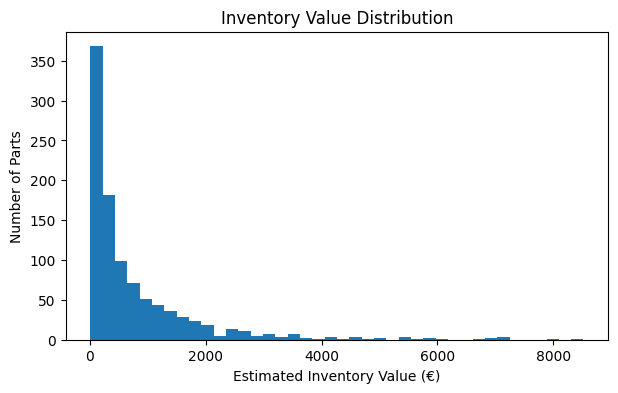

,Part_ID,Part_Name,Equipment_Family_ID,Equipment_Family,Equipment_Model,Part_Category_ID,Part_Category,Demand_Profile,Criticality,Supplier_ID,Supplier_Region,Unit_Cost_EUR,Storage_Type,Lifecycle_Status,Target_Service_Level,Avg_Weekly_Demand_Seed,ABC_Class,Source_Context,Movement_Class,Movement_Lines_36M,Annual_Lines,Avg_Monthly_Lines,Cumulative_Movement_%,Manual_Location,UDC_Type,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Max_Dimension_mm,Min_Dimension_mm,Stock_Managed,Avg_Daily_Qty,Lead_Time_Weeks,Safety_Stock_Qty,Reorder_Point_Qty,Max_Stock_Qty,Stock_Qty,Total_Qty_36M,Total_Volume_cm3,XYZ_Class,Avg_Weekly_Demand,Demand_CV,Available_Qty,Estimated_Inventory_Value
0,TC-CON-0343,Basic Line TC Grease Cartridge,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-015,EU,40.87,Bin,Active,0.94,4.141,A,Anonymised/reconstructed warehouse transition ...,A+,473,157.7,13.14,7.47,R-I38,VER,1543,689,68,72293,1543,68,1,2.300,1.4,18,35,48,46,1795,3470064,Y,3.000000,1.090197,37,1512.19
1,VL-CON-0336,Scissor Lift Air Filter,VL,Vehicle Lift,Scissor Lift,CON,Consumables & service kits,frequent,Medium,SUP-004,EU,29.16,Bin,Active,0.94,4.364,A,Anonymised/reconstructed warehouse transition ...,A+,395,131.7,10.97,13.72,R-B17,D,258,91,20,470,258,20,1,1.706,1.0,13,22,38,23,1331,17860,X,3.852564,0.583625,16,466.56
2,TC-CON-0329,A2024 LL Air Filter,TC,Tyre Changer,A2024 LL,CON,Consumables & service kits,frequent,Medium,SUP-018,EU,43.54,Bin,Active,0.94,3.839,A,Anonymised/reconstructed warehouse transition ...,A+,313,104.3,8.69,18.66,R-E25,B,61,30,42,77,61,30,1,1.272,1.3,13,22,39,23,993,3003,X,3.365385,0.603877,18,783.72
3,WA-CON-0631,Exact Precision Lubrication Kit,WA,Wheel Aligner,Exact Precision,CON,Consumables & service kits,frequent,Medium,SUP-020,EU,26.96,Bin,Active,0.94,4.334,A,Anonymised/reconstructed warehouse transition ...,A+,231,77.0,6.42,22.31,R-F76,D,177,98,143,2480,177,98,1,0.867,1.3,15,21,32,16,677,79360,X,3.602564,0.587932,19,512.24
4,TC-CON-0171,Basic Line TC Air Filter,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-003,EU,40.68,Bin,Active,0.94,4.441,A,Anonymised/reconstructed warehouse transition ...,A+,227,75.7,6.31,25.90,R-L86,B,135,132,46,820,135,46,1,1.030,1.0,6,12,20,17,804,16400,Y,2.929487,1.170425,15,610.20


In [2]:
inventory_segmentation = (
    part_master
    .merge(
        inventory_status[
            [
                "Part_ID",
                "XYZ_Class",
                "Avg_Weekly_Demand",
                "Demand_CV",
                "Available_Qty"
            ]
        ],
        on="Part_ID",
        how="left"
    )
)

inventory_segmentation["Estimated_Inventory_Value"] = (
    inventory_segmentation["Available_Qty"] *
    inventory_segmentation["Unit_Cost_EUR"]
)

plt.figure(figsize=(7,4))

plt.hist(
    inventory_segmentation["Estimated_Inventory_Value"],
    bins=40
)

plt.xlabel("Estimated Inventory Value (€)")
plt.ylabel("Number of Parts")
plt.title("Inventory Value Distribution")

plt.show()

inventory_segmentation.head()

## Movement Class Distribution

Movement class is used to evaluate operational handling frequency and warehouse picking intensity.

This classification is particularly relevant for warehouse automation because high-movement items typically require higher accessibility and prioritisation within warehouse operations.

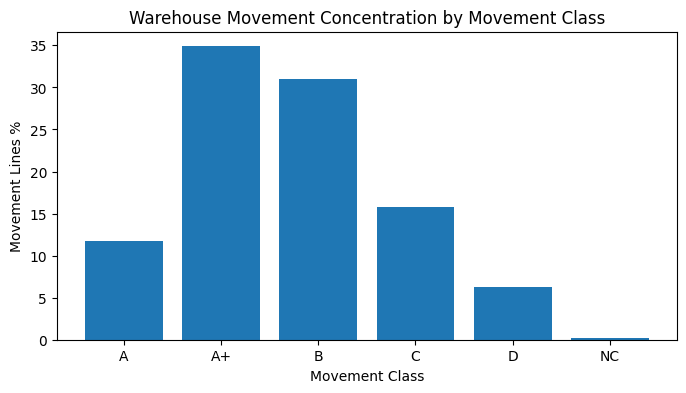

,Movement_Class,Parts,Total_Movement_Lines,Avg_Monthly_Lines,Avg_Available_Qty,Avg_Inventory_Value,Part_%,Movement_Lines_%
0,A,9,742,2.29,14.56,314.49,0.9,11.73
1,A+,8,2207,7.66,23.88,762.18,0.8,34.88
2,B,59,1965,0.93,14.86,199.74,5.9,31.05
3,C,167,1001,0.17,10.75,448.06,16.7,15.82
4,D,338,397,0.03,5.15,575.14,33.8,6.27
5,NC,419,16,0.00,3.10,1186.94,41.9,0.25


In [3]:
movement_summary = (
    inventory_segmentation
    .groupby("Movement_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Avg_Monthly_Lines=("Avg_Monthly_Lines", "mean"),
        Avg_Available_Qty=("Available_Qty", "mean"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

movement_summary["Part_%"] = (
    movement_summary["Parts"] /
    movement_summary["Parts"].sum() * 100
).round(2)

movement_summary["Movement_Lines_%"] = (
    movement_summary["Total_Movement_Lines"] /
    movement_summary["Total_Movement_Lines"].sum() * 100
).round(2)

plt.figure(figsize=(8,4))

plt.bar(
    movement_summary["Movement_Class"],
    movement_summary["Movement_Lines_%"]
)

plt.xlabel("Movement Class")
plt.ylabel("Movement Lines %")
plt.title("Warehouse Movement Concentration by Movement Class")

plt.show()

movement_summary

## ABC Inventory Distribution

ABC classification is used to evaluate inventory concentration and identify which spare parts account for the largest operational and inventory impact within the warehouse.

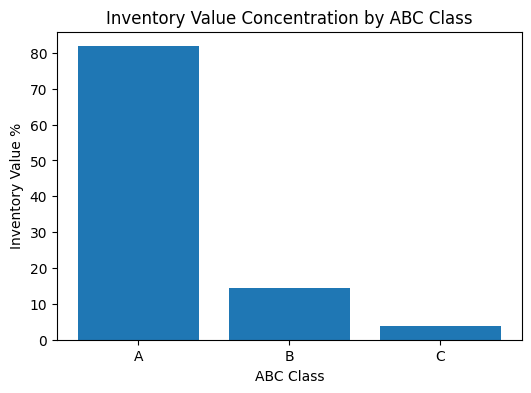

,ABC_Class,Parts,Avg_Unit_Cost,Avg_Weekly_Demand,Avg_Available_Qty,Total_Inventory_Value,Part_%,Inventory_Value_%
0,A,449,396.26,0.24,5.72,643989.51,44.9,81.80
1,B,295,107.91,0.21,5.99,114258.16,29.5,14.51
2,C,256,29.14,0.22,6.63,29016.48,25.6,3.69


In [4]:
abc_summary = (
    inventory_segmentation
    .groupby("ABC_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Unit_Cost=("Unit_Cost_EUR", "mean"),
        Avg_Weekly_Demand=("Avg_Weekly_Demand", "mean"),
        Avg_Available_Qty=("Available_Qty", "mean"),
        Total_Inventory_Value=("Estimated_Inventory_Value", "sum")
    )
    .round(2)
    .reset_index()
)

abc_summary["Part_%"] = (
    abc_summary["Parts"] /
    abc_summary["Parts"].sum() * 100
).round(2)

abc_summary["Inventory_Value_%"] = (
    abc_summary["Total_Inventory_Value"] /
    abc_summary["Total_Inventory_Value"].sum() * 100
).round(2)

plt.figure(figsize=(6,4))

plt.bar(
    abc_summary["ABC_Class"],
    abc_summary["Inventory_Value_%"]
)

plt.xlabel("ABC Class")
plt.ylabel("Inventory Value %")
plt.title("Inventory Value Concentration by ABC Class")

plt.show()

abc_summary

## XYZ Demand Variability Distribution

XYZ classification evaluates demand variability and inventory predictability across the spare-parts population.

Higher variability generally increases:
- replenishment uncertainty
- inventory-risk exposure
- stockout risk
- operational planning complexity

This analysis is particularly relevant for spare-parts environments characterised by intermittent and irregular demand behaviour.

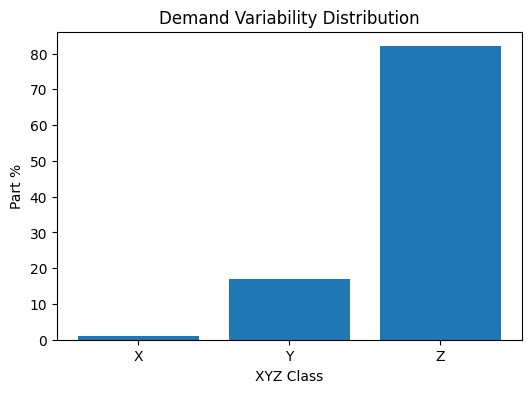

,XYZ_Class,Parts,Avg_Demand_CV,Avg_Weekly_Demand,Avg_Lead_Time,Avg_Inventory_Value,Part_%
0,X,11,0.73,2.82,1.20,384.80,1.1
1,Y,169,1.80,0.81,1.24,358.64,16.9
2,Z,820,6.21,0.07,1.24,881.00,82.0


In [5]:
xyz_summary = (
    inventory_segmentation
    .groupby("XYZ_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Demand_CV=("Demand_CV", "mean"),
        Avg_Weekly_Demand=("Avg_Weekly_Demand", "mean"),
        Avg_Lead_Time=("Lead_Time_Weeks", "mean"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

xyz_summary["Part_%"] = (
    xyz_summary["Parts"] /
    xyz_summary["Parts"].sum() * 100
).round(2)

plt.figure(figsize=(6,4))

plt.bar(
    xyz_summary["XYZ_Class"],
    xyz_summary["Part_%"]
)

plt.xlabel("XYZ Class")
plt.ylabel("Part %")
plt.title("Demand Variability Distribution")

plt.show()

xyz_summary

## Inventory Value Concentration

Inventory concentration analysis helps identify how warehouse value is distributed across the spare-parts population.

This is relevant for warehouse prioritisation and inventory control because a limited number of parts may represent a disproportionately high share of inventory value.

In [6]:
inventory_value_summary = (
    inventory_segmentation
    .groupby("ABC_Class")
    .agg(
        Total_Inventory_Value=("Estimated_Inventory_Value", "sum"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

inventory_value_summary["Inventory_Value_%"] = (
    inventory_value_summary["Total_Inventory_Value"] /
    inventory_value_summary["Total_Inventory_Value"].sum() * 100
).round(2)

inventory_value_summary

,ABC_Class,Total_Inventory_Value,Avg_Inventory_Value,Inventory_Value_%
0,A,643989.51,1434.28,81.80
1,B,114258.16,387.32,14.51
2,C,29016.48,113.35,3.69


## ABC / XYZ Segmentation Matrix

Combining ABC and XYZ classifications helps identify which spare parts require the highest operational attention.

The matrix highlights:
- high-value stable inventory
- high-value intermittent inventory
- replenishment-sensitive items
- operationally critical spare parts
- lower-priority inventory segments

The combined classification is particularly useful for inventory-control prioritisation and warehouse operational evaluations.

In [7]:
abc_xyz_matrix = pd.crosstab(
    inventory_segmentation["ABC_Class"],
    inventory_segmentation["XYZ_Class"],
    margins=True
)

abc_xyz_matrix

XYZ_Class,X,Y,Z,All
ABC_Class,,,,
A,8,63,378,449
B,3,50,242,295
C,0,56,200,256
All,11,169,820,1000


## Movement Class vs ABC Classification

This comparison evaluates the relationship between:
- warehouse movement intensity
- inventory-value concentration

The objective is to determine whether the most operationally active items also represent the highest inventory-value exposure.

For warehouse operations and automation planning, movement intensity may be operationally more important than inventory value alone.

In [8]:
movement_abc_matrix = pd.crosstab(
    inventory_segmentation["Movement_Class"],
    inventory_segmentation["ABC_Class"],
    margins=True
)

movement_abc_matrix

ABC_Class,A,B,C,All
Movement_Class,,,,
A,6,3,0,9
A+,8,0,0,8
B,19,19,21,59
C,65,49,53,167
D,155,97,86,338
NC,196,127,96,419
All,449,295,256,1000


## High-Risk Inventory Segments

Special operational attention is typically required for:
- high-value unpredictable items
- long lead-time components
- high-movement critical parts
- operationally sensitive inventory

In [ ]:
# High-risk inventory: 
    # high-value OR high-movement parts
    # combined with unpredictable demand OR criticality

high_risk_inventory = inventory_segmentation[
    (
        (inventory_segmentation["ABC_Class"] == "A") |
        (inventory_segmentation["Movement_Class"].isin(["A+", "A"]))
    ) &
    (
        (inventory_segmentation["XYZ_Class"] == "Z") |
        (inventory_segmentation["Criticality"] == "Critical")
    )
]

high_risk_inventory[
    [
        "Part_ID",
        "Part_Name",
        "Part_Category",
        "Movement_Class",
        "ABC_Class",
        "XYZ_Class",
        "Criticality",
        "Supplier_Region",
        "Lead_Time_Weeks",
        "Available_Qty",
        "Estimated_Inventory_Value"
    ]
].head(20)

high risk inventory: Criticality
Critical    139462.33
High        237380.00
Low          38143.59
Medium      177745.03
Name: Estimated_Inventory_Value, dtype: float64


In [18]:
# Count rows for each unique Criticality value
criticality_counts = high_risk_inventory["Criticality"].value_counts()
print("high risk inventory:\n", criticality_counts)

criticality = part_master["Criticality"].value_counts()
print("all dataset:\n", criticality)

high risk inventory:
 Criticality
High        146
Medium      132
Critical     67
Low          34
Name: count, dtype: int64
all dataset:
 Criticality
Medium      365
High        333
Low         163
Critical    139
Name: count, dtype: int64


## Critical Spare Parts

Critical spare parts require higher operational visibility because stockouts may directly affect maintenance continuity, equipment availability, and warehouse service performance.

In [10]:
critical_inventory = inventory_segmentation[
    inventory_segmentation["Criticality"] == "Critical"
]

critical_summary = (
    critical_inventory
    .groupby(
        ["Movement_Class", "ABC_Class", "XYZ_Class"]
    )
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Lead_Time=("Lead_Time_Weeks", "mean"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean"),
        Avg_Weekly_Demand=("Avg_Weekly_Demand", "mean")
    )
    .round(2)
    .reset_index()
)

critical_summary

,Movement_Class,ABC_Class,XYZ_Class,Parts,Avg_Lead_Time,Avg_Inventory_Value,Avg_Weekly_Demand
0,B,A,Y,1,1.40,305.46,1.08
1,C,A,Z,1,1.00,331.87,0.23
2,C,B,Y,2,1.05,159.95,0.55
3,C,B,Z,1,1.00,123.66,0.30
4,D,A,Z,8,1.11,633.75,0.09
5,D,B,Z,7,1.14,388.15,0.15
6,D,C,Z,5,1.48,151.10,0.16
7,NC,A,Z,57,1.20,2346.58,0.00
8,NC,B,Z,38,1.26,723.68,0.01
9,NC,C,Z,19,1.24,221.19,0.00


In [ ]:
abc_summary.to_csv(OUTPUT_DIR / "abc_summary.csv", index=False)
xyz_summary.to_csv(OUTPUT_DIR / "xyz_summary.csv", index=False)
movement_summary.to_csv(OUTPUT_DIR / "movement_summary.csv", index=False)
high_risk_inventory.to_csv(OUTPUT_DIR / "high_risk_inventory.csv", index=False)
critical_summary.to_csv(OUTPUT_DIR / "critical_inventory_summary.csv", index=False)

## Operational Observations

The analyses confirm a strong concentration of operational importance within a relatively limited subset of spare parts.

The inventory structure shows:
- concentration of inventory value within A-class inventory
- concentration of warehouse activity within high-movement items
- intermittent and irregular demand behaviour typical of spare-parts environments
- operational exposure associated with critical and unpredictable inventory
- relevance of lead-time and replenishment considerations for inventory prioritisation
- operational differences between inventory-value importance and warehouse movement intensity

These characteristics are consistent with industrial spare-parts warehouse environments and provide the operational basis for:
- inventory-control evaluations
- replenishment analyses
- warehouse operational assessments
- automated warehouse feasibility and allocation analyses